This notebook is to illustrate different consolidation indcators to show the pros and cons how much the differences are.

In [1]:
import sys

In [2]:
sys.path.append("../../src/")

In [59]:
from pandas_ta.volatility import bbands
from sts.data.datatable.tables import sp500_datatable
from sts.plots.time_series_plots import plot_multi_time_series
import pandas as pd

## bbands to detect consolidation periods

In [62]:
amd = sp500_datatable["AMD"]
df = amd.history(start="2024-04-01", end="2024-07-17", interval="1d")

AMD: No data found for this date range, symbol may be delisted


In [63]:
import yfinance as yf

In [76]:
ticker = yf.Ticker("DIT")
ticker.history(start="2020-11-06", end="2020-12-23")

DIT: No data found for this date range, symbol may be delisted


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,


In [53]:
bb_df = bbands(df["Close"], 20)

In [54]:
bb_df.columns = ["BBL", "BBM", "BBU", "BBB", "BBP"]

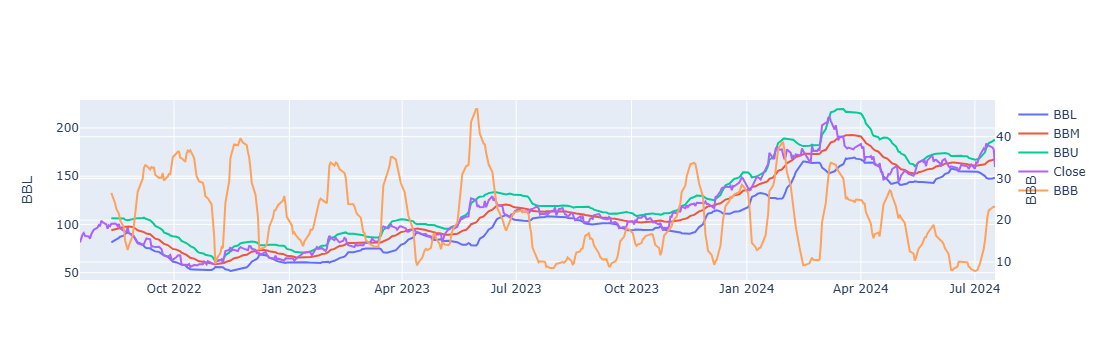

In [55]:
plot_multi_time_series(
    [bb_df["BBL"], bb_df["BBM"], bb_df["BBU"], df["Close"], bb_df["BBB"]],
    yaxis_list=["y1", "y1", "y1", "y1", "y2"],
    yaxis_left=[True, True, True, True, False],
)

for bbands, it is better to use close price for the vol detection, in this amd examples, 

In [73]:
import yfinance as yf

# Define the ticker symbol
ticker = "AAPL"

# Get historical market data


# Display the first few rows of the data
print(data.head())

[*********************100%***********************]  1 of 1 completed

1 Failed download:
- AAPL: No data found for this date range, symbol may be delisted
Empty DataFrame
Columns: [Open, High, Low, Close, Adj Close, Volume]
Index: []


In [77]:
%%debug
ticker.history(start="2020-11-06", end="2020-12-23")

NOTE: Enter 'c' at the ipdb>  prompt to continue execution.
None
> <string>(2)<module>()



ipdb>  s


--Call--
> /home/yuqing/miniconda3/lib/python3.10/site-packages/yfinance/base.py(545)history()
    543         return data
    544 
--> 545     def history(self, period="1mo", interval="1d",
    546                 start=None, end=None, prepost=False, actions=True,
    547                 auto_adjust=True, back_adjust=False, repair=False, keepna=False,



ipdb>  s


> /home/yuqing/miniconda3/lib/python3.10/site-packages/yfinance/base.py(597)history()
    595         """
    596 
--> 597         if start or period is None or period.lower() == "max":
    598             # Check can get TZ. Fail => probably delisted
    599             tz = self._get_ticker_tz(debug, proxy, timeout)



...

> /home/yuqing/miniconda3/lib/python3.10/site-packages/yfinance/base.py(681)history()
    679 
    680         err_msg = "No data found for this date range, symbol may be delisted"
--> 681         fail = False
    682         if data is None or not type(data) is dict:
    683             fail = True



ipdb>  


> /home/yuqing/miniconda3/lib/python3.10/site-packages/yfinance/base.py(682)history()
    680         err_msg = "No data found for this date range, symbol may be delisted"
    681         fail = False
--> 682         if data is None or not type(data) is dict:
    683             fail = True
    684         elif type(data) is dict and 'status_code' in data:



ipdb>  c


DIT: No data found for this date range, symbol may be delisted


> /home/yuqing/miniconda3/lib/python3.10/site-packages/yfinance/base.py(654)history()
    652             if end is not None:
    653                 end_dt = _pd.Timestamp(end, unit='s').tz_localize("UTC")
--> 654                 dt_now = end_dt.tzinfo.localize(_datetime.datetime.utcnow())
    655                 data_delay = _datetime.timedelta(minutes=30)
    656                 if end_dt+data_delay <= dt_now:



ipdb>  dt_now = end_dt.tzinfo.localize(_datetime.datetime.utcnow())
*** AttributeError: 'datetime.timezone' object has no attribute 'localize'

In [ ]:
# 1608699600 for 2020-12-23
# 1604638800 for 2020-11-06